In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sheet_id = "1RVnUAGVsr4lrt7nZ2WOq2hFkj7gFcRef"
sheet_name = "Orders"  # or the visible tab name

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

df

In [ ]:
df.dtypes

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
df["Year_status"]= df["Order Date"].dt.year.apply(lambda x : "After 2015" if x>2015 else "Before 2015")

In [ ]:
df["Month"] = df["Order Date"].dt.month

In [ ]:
df1 = df[df["Year_status"]=='Before 2015']
df2 = df[df["Year_status"]=='After 2015']

In [ ]:
#before 2015
df3=df1.groupby("Month").agg(Avg_sales=("Sales","mean")).reset_index()

In [ ]:
#after 2015
df4=df2.groupby("Month").agg(Avg_sales=("Sales","mean")).reset_index()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Added 'line_red,' and 'line_blue,' (notice the commas)
# and removed 'line2' from the title.

line_red, = plt.plot(
    df3["Month"],
    df3["Avg_sales"],
    linewidth=1,
    linestyle="--",
    marker="o",
    markersize=8,
    markerfacecolor="red",
    markeredgewidth=2,
    color="red",
    label="Before 2015"  # Best practice: add label here
)

line_blue, = plt.plot(
    df4["Month"],
    df4["Avg_sales"],
    linewidth=1,
    linestyle="--",
    marker="+",
    markersize=8,
    markerfacecolor="blue",
    markeredgewidth=2,
    color="blue",
    label="After 2015"   # Best practice: add label here
)

# Do not assign plt.title to a variable for the legend
plt.title(
    "Average Sales per Month",
    fontsize=18,
    fontweight="bold",
    pad=10
)

plt.xlabel("Year", fontsize=13, labelpad=10)
plt.ylabel("Average Sales", fontsize=13, labelpad=10)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 2. FIXED: use a comma in the list and use the actual plot variables
plt.legend(handles=[line_red, line_blue], loc="lower right", title="Legend")

plt.grid(
    True,
    linestyle=":",
    linewidth=0.8,
    alpha=0.8
)

plt.show()

In [ ]:
for i,j in zip(df["Year_status"].unique(),["black","red"]):
  df1 = df[df["Year_status"]==i]
  df3=df1.groupby("Month").agg(Avg_sales=("Sales","mean")).reset_index()
  plt.plot(df3["Month"],df3["Avg_sales"],color=j) #before 2015

In [ ]:
for i,j,k in zip(df["Year_status"].unique(),["black","red"],["o","+"]):
  df1 = df[df["Year_status"]==i]
  df3=df1.groupby("Month").agg(Avg_sales=("Sales","mean")).reset_index()
  plt.plot(df3["Month"],df3["Avg_sales"],color=j,marker=k)

In [ ]:
a = [1,2,3]
b = [6,7,8]

for i,j in zip(a,b):
  print(i,j)

In [ ]:
for i,j in zip(df["Year_status"].unique(),["black","red"]):
  print(i,j)

In [ ]:
df.columns

In [ ]:
#top 5 customers with highest sales - bar chart

In [ ]:
df.groupby(["Customer Name"]).agg(Total_sales=("Sales","sum")).reset_index().sort_values("Total_sales",ascending=False).head()

In [ ]:
df1=df.groupby(["Customer Name"]).agg(Total_sales=("Sales","sum")).reset_index().sort_values("Total_sales",ascending=False).head()
print(df1)

plt.figure(figsize=(8, 5))

plt.barh(
    df1["Customer Name"],
    df1["Total_sales"],color="orange"
)

plt.xticks(rotation=90, fontsize=10)

#plt.ylim(700000, 850000)

plt.title("Top 5 customers with highest sales", fontsize=14, fontweight="bold")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")

plt.grid(axis="x", linestyle=":", alpha=0.1)

plt.show()

In [ ]:
#line chart - Trend Analysis,
#bar/chart- comparison between the categories
#pie chart - porportion / percentage split between the categories
#donut chart -adding white circle


In [ ]:
#histogram is used to understand the spread
#data distribution


In [20]:
import seaborn as sns
df = sns.load_dataset("tips")

In [21]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [22]:
df["total_bill"].describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


(array([ 1.,  1.,  5.,  5., 20., 17., 24., 18., 26., 23., 15., 13., 11.,
        13.,  7.,  7.,  7.,  5.,  5.,  5.,  2.,  2.,  2.,  3.,  0.,  2.,
         1.,  0.,  3.,  1.]),
 array([ 3.07      ,  4.66133333,  6.25266667,  7.844     ,  9.43533333,
        11.02666667, 12.618     , 14.20933333, 15.80066667, 17.392     ,
        18.98333333, 20.57466667, 22.166     , 23.75733333, 25.34866667,
        26.94      , 28.53133333, 30.12266667, 31.714     , 33.30533333,
        34.89666667, 36.488     , 38.07933333, 39.67066667, 41.262     ,
        42.85333333, 44.44466667, 46.036     , 47.62733333, 49.21866667,
        50.81      ]),
 <BarContainer object of 30 artists>)

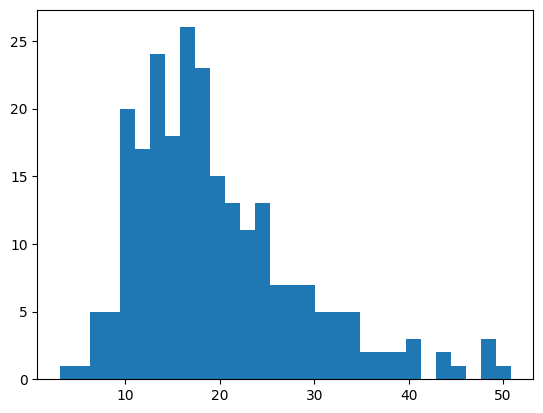

In [23]:
plt.hist(df["total_bill"], bins=30
         )

In [24]:
#scatter plot
#correlation
df[["total_bill","tip"]].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


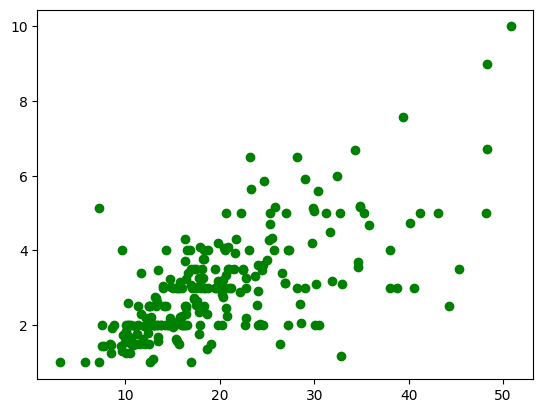

In [25]:
plt.scatter(df["total_bill"],df["tip"],color="green")

,lucky_number,price
lucky_number,1.000000,-0.036107
price,-0.036107,1.000000


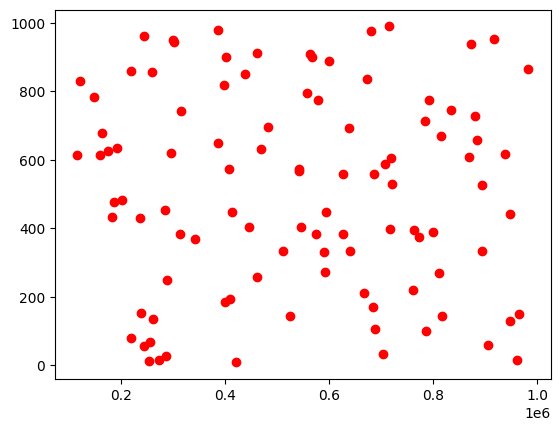

In [26]:
import numpy as np
lucky_number = np.random.randint(100000,1000000,100)
price = np.random.randint(1,1000,100)

plt.scatter(lucky_number,price,color= "red")

pd.DataFrame({"lucky_number":lucky_number,"price":price}).corr()


#Boxplot

In [27]:
#detect the oulier
age = [23,24,25,30,34,50,61, 100]
np.array(age).mean()

np.float64(43.375)

{'whiskers': [<matplotlib.lines.Line2D at 0x781b977d5280>,
 'caps': [<matplotlib.lines.Line2D at 0x781b977d5880>,
 'boxes': [<matplotlib.lines.Line2D at 0x781b977d5010>],
 'medians': [<matplotlib.lines.Line2D at 0x781b977d5df0>],
 'fliers': [<matplotlib.lines.Line2D at 0x781b977d60c0>],
 'means': []}

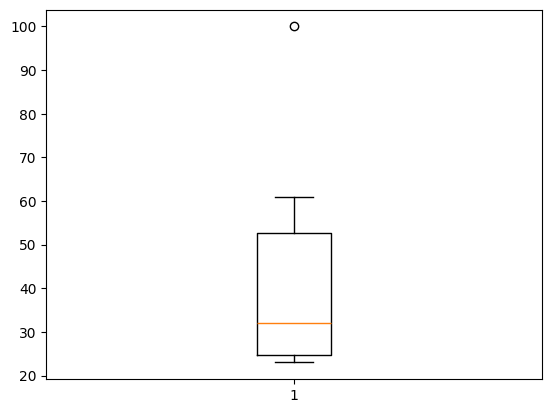

In [28]:
plt.boxplot(age)

In [29]:
monthly_income = [2000,4000,3000,3800,5000,52000,60000,1000000,1250000]

np.array(monthly_income).mean()

np.float64(264422.22222222225)

{'whiskers': [<matplotlib.lines.Line2D at 0x781b9778f740>,
 'caps': [<matplotlib.lines.Line2D at 0x781b9778fcb0>,
 'boxes': [<matplotlib.lines.Line2D at 0x781b9778c380>],
 'medians': [<matplotlib.lines.Line2D at 0x781b97584290>],
 'fliers': [<matplotlib.lines.Line2D at 0x781b97584590>],
 'means': []}

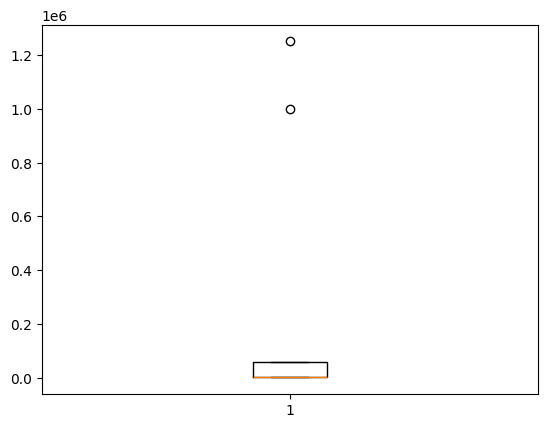

In [30]:
plt.boxplot(monthly_income)

{'whiskers': [<matplotlib.lines.Line2D at 0x781b975a3140>,
 'caps': [<matplotlib.lines.Line2D at 0x781b975a36e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x781b975a2ea0>],
 'medians': [<matplotlib.lines.Line2D at 0x781b975a3c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x781b975a3f50>],
 'means': []}

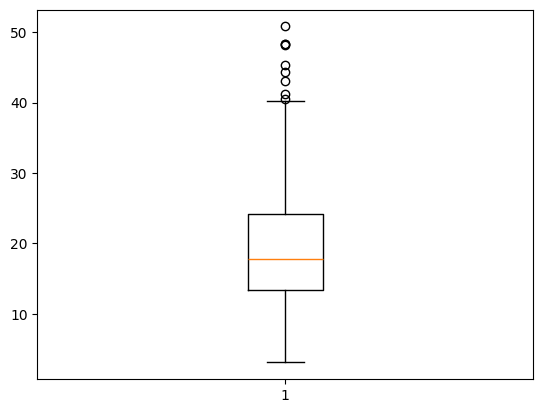

In [31]:
plt.boxplot(df["total_bill"])

<Axes: >

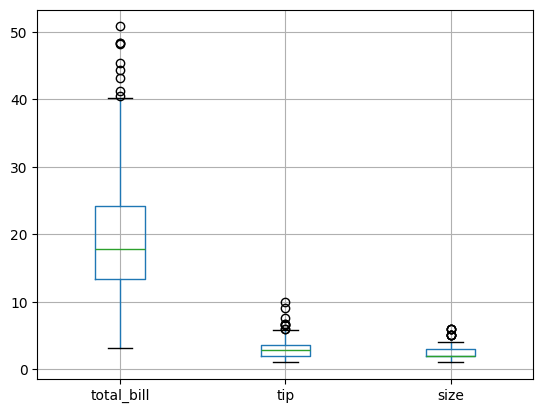

In [32]:
df.boxplot()

**Skew**

In [33]:
a = [1,2,3,4,5]
pd.Series(a).skew()

np.float64(0.0)

{'whiskers': [<matplotlib.lines.Line2D at 0x781b97651730>,
 'caps': [<matplotlib.lines.Line2D at 0x781b97654680>,
 'boxes': [<matplotlib.lines.Line2D at 0x781b97653f80>],
 'medians': [<matplotlib.lines.Line2D at 0x781b97654cb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x781b97654f80>],
 'means': []}

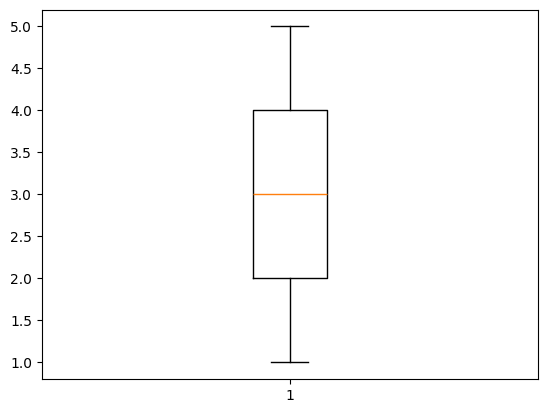

In [34]:
plt.boxplot(a)

In [37]:
import numpy as np
import pandas as pd

a = [1,2,3,4,5,6,7,8,100]

np.array(a).mean()
pd.Series(a).skew()

np.float64(2.9702269936769006)

{'whiskers': [<matplotlib.lines.Line2D at 0x781b9749c050>,
 'caps': [<matplotlib.lines.Line2D at 0x781b9749e570>,
 'boxes': [<matplotlib.lines.Line2D at 0x781b9749e7e0>],
 'medians': [<matplotlib.lines.Line2D at 0x781b97a939e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x781b97544d40>],
 'means': []}

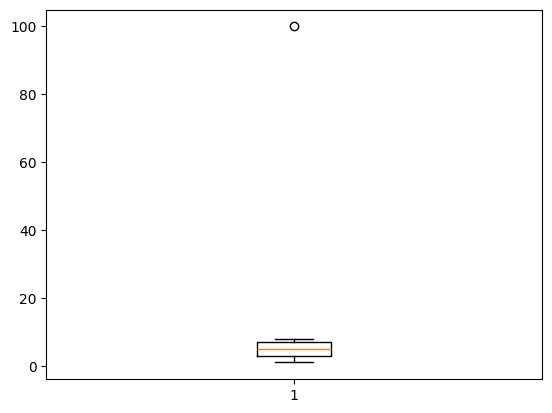

In [38]:
plt.boxplot(a)

In [39]:
# no skew - -0.5 to 0.5
# right skew >0.5
# left skew < 0.5

In [40]:
#Top 3 sub-category performing well - samples superstore

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sheet_id = "1RVnUAGVsr4lrt7nZ2WOq2hFkj7gFcRef"
sheet_name = "Orders"  # or the visible tab name

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,01-21-2014,23/1/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,02-26-2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,02-26-2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,02-26-2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [42]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [43]:
df1 = df.groupby(["Sub-Category"]).agg(Total_sales=("Sales","sum")).reset_index().sort_values("Total_sales",ascending=False).head(3)

   Sub-Category  Total_sales
13       Phones   330007.054
5        Chairs   328449.103
14      Storage   223843.608


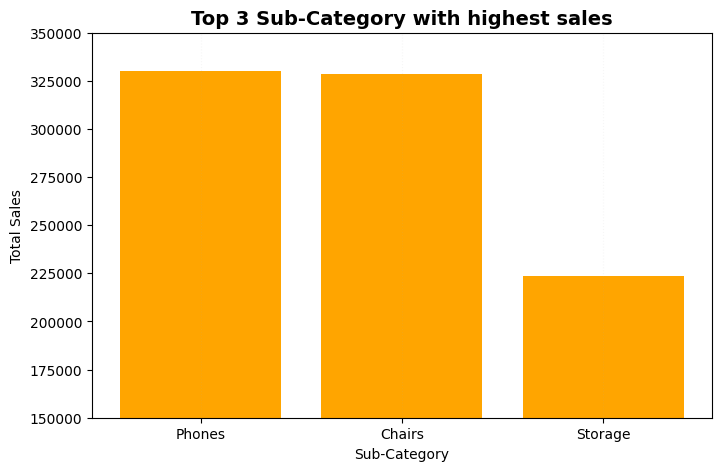

In [44]:
df1 = df.groupby(["Sub-Category"]).agg(Total_sales=("Sales","sum")).reset_index().sort_values("Total_sales",ascending=False).head(3)
print(df1)

plt.figure(figsize=(8, 5))

plt.bar(
    df1["Sub-Category"],
    df1["Total_sales"],color="orange"
)

plt.xticks(fontsize=10)

plt.ylim(150000, 350000)

plt.title("Top 3 Sub-Category with highest sales", fontsize=14, fontweight="bold")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")

plt.grid(axis="x", linestyle=":", alpha=0.1)

plt.show()

In [45]:
#matplotlib -> seaborn -> plotly

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [47]:
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
